<Axes: xlabel='tmax', ylabel='tmax_tomorrow'>

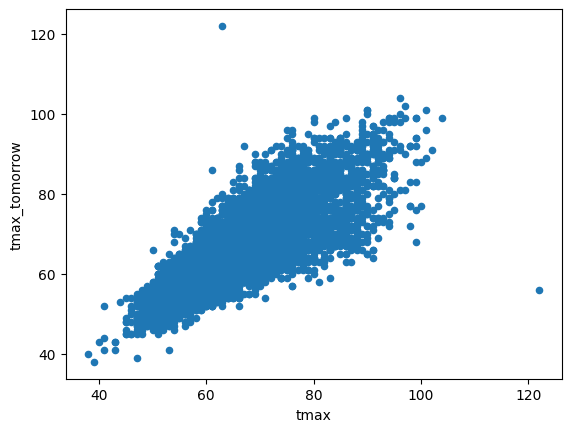

In [ ]:
import pandas as pd

# Load the local weather dataset
data = pd.read_csv('clean_weather.csv', index_col = 0) # first collumn of dataset is the index collumm
data = data.ffill()

data.plot.scatter("tmax", "tmax_tomorrow")

In [5]:
data.corr()

,tmax,tmin,rain,tmax_tomorrow
tmax,1.000000,0.615604,-0.219941,0.818561
tmin,0.615604,1.000000,-0.019546,0.585572
rain,-0.219941,-0.019546,1.000000,-0.211799
tmax_tomorrow,0.818561,0.585572,-0.211799,1.000000


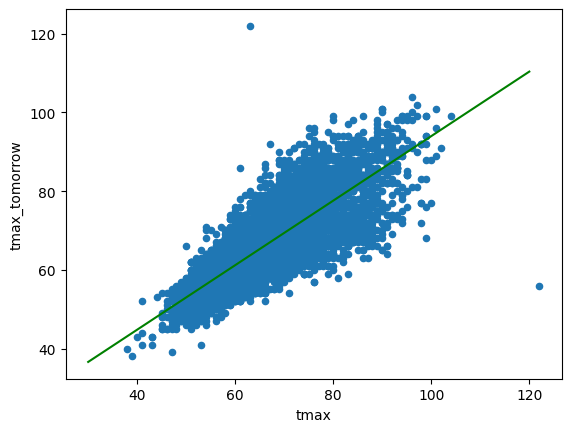

In [ ]:
import matplotlib.pyplot as plt

data.plot.scatter("tmax", "tmax_tomorrow")

prediction = lambda x, w1 = 0.82, b = 11.99: x * w1 + b # uses weights from correlation?

plt.plot([30, 120], [prediction(30), prediction(120)], 'green')

In [9]:
import numpy as np

def mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)

print(mse(data["tmax_tomorrow"], prediction(data["tmax"])))

print(mse(data["tmax_tomorrow"], prediction(data["tmax"], 0.83)))

print(mse(data["tmax_tomorrow"], prediction(data["tmax"], 0.82, 13)))

22.897335324598416
23.474003804870822
24.118285439336727


C:\Users\asher\AppData\Local\Temp\ipykernel_28344\690064015.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_ratio = ratios.groupby(tmax_bins).mean()
C:\Users\asher\AppData\Local\Temp\ipykernel_28344\690064015.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_tmax = data["tmax"].groupby(tmax_bins).mean()


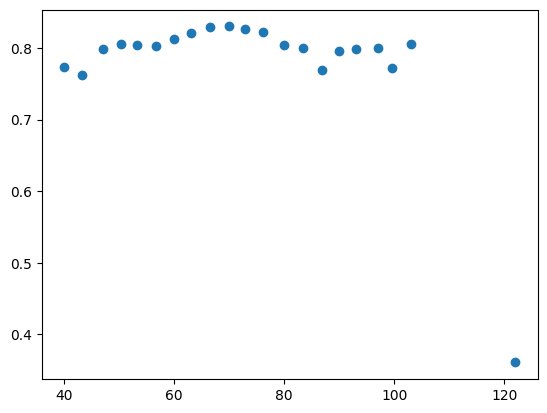

In [12]:
tmax_bins = pd.cut(data["tmax"], 25)

ratios = (data["tmax_tomorrow"] - 11.99) / data["tmax"]
binned_ratio = ratios.groupby(tmax_bins).mean()

#tmax_bins
binned_ratio # shows how the ratio of tmax_tomorrow to tmax changes across different bins of tmax

binned_tmax = data["tmax"].groupby(tmax_bins).mean()
plt.scatter(binned_tmax, binned_ratio)

Neural networks add a nonlinear transformation on top of the linear transformations.
Multiple layers, which can capture interactions between features.
Multiple hidden units, whci hhave slightly different linear and nonlinear transformations. 

$ y = wx + b$
$ y = relu(wx + b)$

## Activation Functions

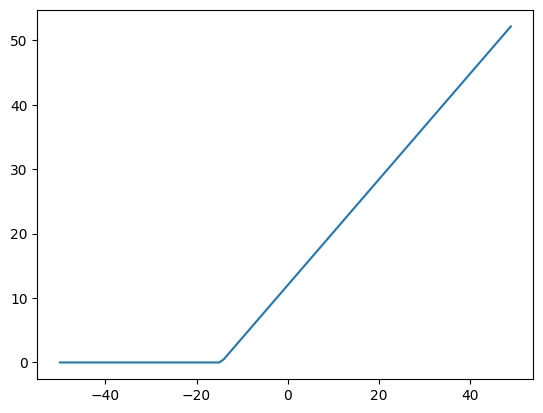

In [ ]:
temps = np.arange(-50,50)

# Relu activation function
plt.plot(temps, np.maximum(0, prediction(temps)))

$ \hat{y} = w_{2} relu(w_{1}x + b_{1}) + b_{2} $ # two layer of neural network

(0.0, 40.0)

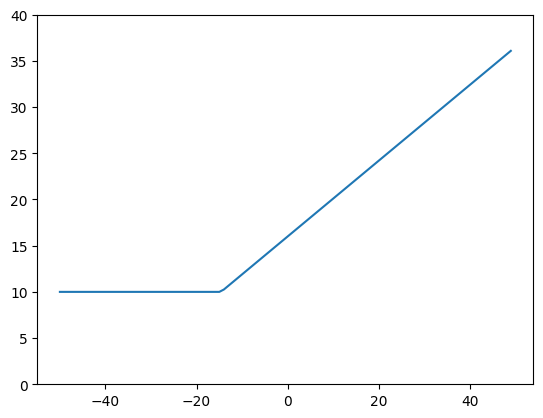

In [ ]:
# Multiple layers
temps = np.arange(-50,50)

layer1 = np.maximum(0, prediction(temps))
layer2 = prediction(layer1, 0.5, 10)  #network would learn correct weights and biases to get correct values

plt.plot(temps, layer2)

plt.ylim((0,40))

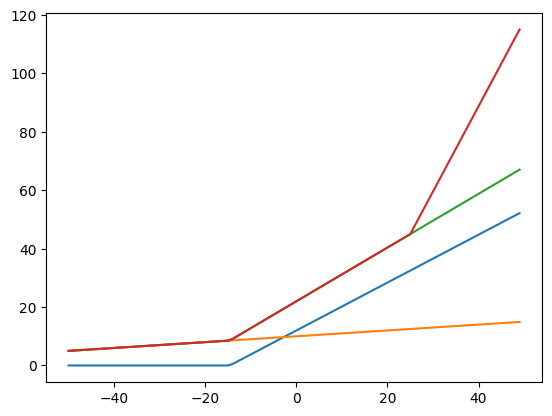

In [21]:
# Multiple hidden units per layer

layer1_1 = np.maximum(0, prediction(temps))
layer1_2 = np.maximum(0, prediction(temps, 0.1, 10))
layer1_3 = np.maximum(0, prediction(temps, 2, -50))

plt.plot(temps, layer1_1)
plt.plot(temps, layer1_2)
plt.plot(temps, layer1_1 + layer1_2)
plt.plot(temps, layer1_1 + layer1_2 + layer1_3)


for layer1_2 means relu function is never activated. therefore in this unti all of the information is being passed through, whereas in layer1_1 the relu activation feature is activated and so there are a number of zeros. 

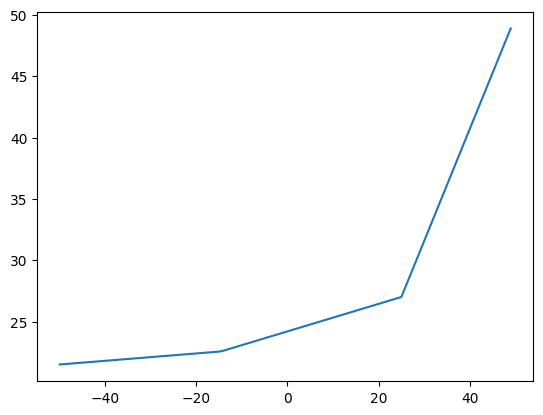

In [ ]:
layer2 = layer1_1 * 0.1 + layer1_2 * 0.3 + layer1_3 * 0.4 + 20 # neural networ would learn weights and biases
plt.plot(temps, layer2)

## The Forward Pass

In [ ]:
input = np.array([[80], [90], [100], [-20], [-10]])

l1_weights = np.array([[0.82, 0.1]])
l1_bias = np.array([[11.99, 10]])

l1_output = input @ l1_weights + l1_bias
l1_output

array([[77.59, 18.  ],
       [85.79, 19.  ],
       [93.99, 20.  ],
       [-4.41,  8.  ],
       [ 3.79,  9.  ]])

In [27]:
l1_activated = np.maximum(l1_output, 0)
l1_activated

array([[77.59, 18.  ],
       [85.79, 19.  ],
       [93.99, 20.  ],
       [ 0.  ,  8.  ],
       [ 3.79,  9.  ]])

$layer_{1} = relu(XW_{1} + B_{1})$

$ \hat{y} = W_{2} relu(W_{1}X + B_{1}) + B_{2} $ # two layer of neural network


Your weights, the number of rows in your weights is the same number of columns in your input and the number of columns in your weights is the number of features in your output. 

In [28]:
l2_weights = np.array([
    [0.5],
    [0.2]
])

l2_bias = np.array([[5]])

output = l1_activated @ l2_weights + l2_bias
output

array([[47.395],
       [51.695],
       [55.995],
       [ 6.6  ],
       [ 8.695]])

We can calculate our weights and biases using gradient descent. 

In [31]:
tmax = np.array([[80], [90], [100], [-20], [-10]])
tmax_tomorrow = np.array([[83], [89], [95], [-22], [-9]])

In [34]:
def mse(actual, predicted):
    return (actual - predicted) ** 2

In [35]:
mse(tmax_tomorrow, output)

array([[1267.716025],
       [1391.663025],
       [1521.390025],
       [ 817.96    ],
       [ 313.113025]])

In [ ]:
def mse_grad(actual, predicted): # gradient of the mean squared error loss function with respect to the predicted values
    return predicted - actual

In [37]:
mse_grad(tmax_tomorrow, output)

array([[-35.605],
       [-37.305],
       [-39.005],
       [ 28.6  ],
       [ 17.695]])

## The Backwards Pass

Reverse the operations of forward pass through the network. 
Goal is to calculate the partial derivative of loss wrt each parameter in the network. Staert with loss wrt output (output of mse_grad function) this is our layer two output gradient, use this to update our layer two weights: Multiply the input to layer two (layer 1 output in the forward pass) by the output gradient (layer two gradient). This tells us how much to update the weights by. We update the bias by the average of the output gradient.

Then pass gradient through to layer 1. Multiply the output gradient by the layer2 weights to get layer1 output gradient. Pull gradient across the relu function (relu derivative), then use this to update weights and bias in Layer1

In [39]:
output_gradient = mse_grad(tmax_tomorrow, output)

In [40]:
l2_w_gradient = l1_activated.T @ output_gradient

l2_w_gradient

array([[-9562.0038],
       [-1741.73  ]])

In [42]:
!pip install sympy

   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   -------- ------------------------------- 1.3/6.3 MB 8.4 MB/s eta 0:00:01
   ------------------ --------------------- 2.9/6.3 MB 8.0 MB/s eta 0:00:01
   -------------------------- ------------- 4.2/6.3 MB 7.6 MB/s eta 0:00:01
   ------------------------------------ --- 5.8/6.3 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 7.2 MB/s  0:00:00
   ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
   ---------------------------------------- 536.2/536.2 kB 4.4 MB/s  0:00:00

   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\asher\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [43]:
from sympy import symbols, diff

In [46]:
x, w = symbols('X, W')
sympy_output = x * w
diff(sympy_output, w)

X

In [ ]:
l2_b_gradient = np.mean(output_gradient, axis=0)

l2_b_gradient

array([-13.124])

In [48]:
l2_weights

array([[0.5],
       [0.2]])

In [49]:
lr = 1e-5 #(small learning rate to prevent overshooting)

l2_bias = l2_bias - lr * l2_b_gradient
l2_weights  = l2_weights - lr * l2_w_gradient 

l2_bias
l2_weights

array([[0.59562004],
       [0.2174173 ]])

## Layer 1 Gradients

In [50]:
l1_activated_gradient = output_gradient @ l2_weights.T
l1_activated_gradient

array([[-21.20705145,  -7.74114297],
       [-22.21960552,  -8.11075238],
       [-23.23215958,  -8.48036179],
       [ 17.03473309,   6.21813478],
       [ 10.53949657,   3.84719912]])

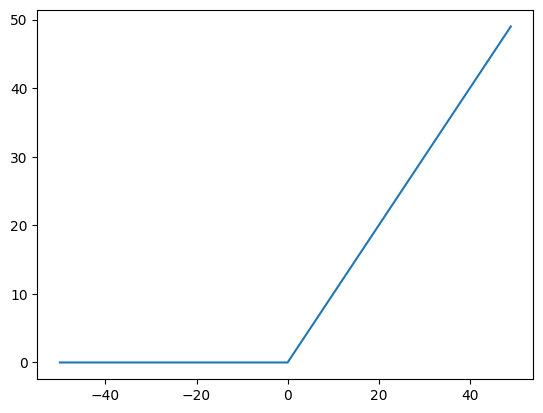

In [51]:
temps = np.arange(-50,50)
plt.plot(temps, np.maximum(0, temps))

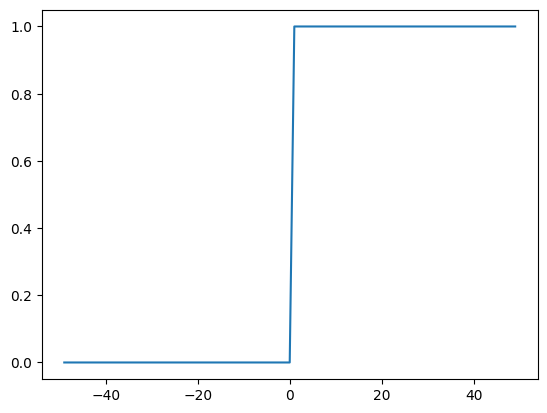

In [ ]:
# Derivative of relu function is 0 for negative inputs and 1 for positive inputs
activation = np.maximum(0, temps)

plt.plot(temps[1:], activation[1:] - np.roll(activation,1)[1:]) # derivative of relu is 0 for negative inputs and 1 for positive inputs

In [54]:
l1_output_gradient = l1_activated_gradient * np.heaviside(l1_output, 0) # gradient of the loss with respect to the output of the first layer, taking into account the activation function
l1_output_gradient

array([[-21.20705145,  -7.74114297],
       [-22.21960552,  -8.11075238],
       [-23.23215958,  -8.48036179],
       [  0.        ,   6.21813478],
       [ 10.53949657,   3.84719912]])

In [ ]:
l1_weight_gradient = input.T @ l1_output_gradient
l1_bias_gradient = np.mean(l1_output_gradient, axis=0)  # This part is back propagation, where we calculate the gradients for the weights and biases of the first layer based on the output gradient and the input to that layer

l1_weights = l1_weights - lr * l1_weight_gradient # This part is gradient descent, where we update the weights and biases of the first layer using the calculated gradients and the learning rate
l1_bias = l1_bias - lr * l1_bias_gradient

In [57]:
l1_weights

array([[0.82, 0.1 ]])

In [58]:
l1_bias

array([[11.99, 10.  ]])

## Network Training Algorithm

Rough Algorithm we followed:
1) Run the network forward pass and ge thte output
2) Compute gradient wrt the outputs for the network. (mse_grad function)
3) For each layer in the network:
    - Compute the gradient wrt the pre-nonlinearity output (if layer has a nonlinearity)
    - Compute the gradient wrt the weights
    - Compute the gradient wrt the biases
    - Compute the gradient wrt the inputs to the layer
4) Update the parameters in the network using gradient descent

batch size = number of exmples passing through your forward and backward pass at once. In above example we have 5 input so batch_size = 5.
Generally larger batch_size means better network performance (it will run faster) and changes wont be overly influenced by single training examples, but may descend less effectively as you don't have as many chances to update its parameters and so will descent slowly. 

## Full Network Implementation

In [61]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from numpy import random

PREDICTORS = ["tmax", "tmin", "rain"]
TARGET = "tmax_tomorrow"

scaler = StandardScaler()
data[PREDICTORS] = scaler.fit_transform(data[PREDICTORS])

split_data = np.split(data, [int(0.7 * len(data)), int(0.85 * len(data))])
(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = [(split[PREDICTORS].to_numpy(), split[[TARGET]].to_numpy()) for split in split_data]


C:\Users\asher\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [69]:
def init_layers(inputs):
    layers = []
    for i in range(1, len(inputs)):
        layers.append([
            # shape of weights is number of columns in previous layer (inputs[i-1]) by number of columns in current layer (inputs[i])
            np.random.rand(inputs[i-1], inputs[i]) / 5 - 0.1, # scale to be between -0.1 and 0.1, to make network converge and descend more effectively (when weights are properly scaled)
            np.ones((1, inputs[i])) # shape of bias is 1 by the number of columns in the current layer
        ])
    return layers

layer_conf = [3, 10, 10, 1] # 3 input features, 10 neurons (features) in first hidden layer, 10 neurons (features) in second hidden layer, 1 output neuron

layers = init_layers(layer_conf)

In [70]:
layers

[[array([[ 0.01038497,  0.04450003,  0.06605095,  0.04183218,  0.08272895,
          -0.08008738, -0.05669391, -0.07776324,  0.03759512,  0.08321879],
         [-0.01336933,  0.02008812, -0.00329964, -0.05673676, -0.02989636,
           0.09095736,  0.04881634, -0.06556827,  0.01170868,  0.05037695],
         [ 0.05252739,  0.04796326, -0.00933056, -0.04694093,  0.08583034,
           0.09481369,  0.00816743,  0.03761894, -0.03823189, -0.03407425]]),
  array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])],
 [array([[ 0.02643893,  0.03941727, -0.03273448, -0.03597706, -0.0396621 ,
          -0.08095683, -0.03461058,  0.02241832,  0.04224141, -0.04704971],
         [-0.03839579, -0.08485766, -0.00767649, -0.08985017,  0.04957778,
           0.06661735, -0.02520642, -0.0360735 , -0.02447173, -0.04039795],
         [ 0.02058733,  0.05839421,  0.01691045,  0.02780505,  0.01633608,
          -0.01852009, -0.09578405,  0.07554875,  0.00535222,  0.03233071],
         [-0.0014074 ,  0.01835424, -0

In [80]:
def forward(batch, layers):
    hiddens = [batch.copy()]
    for i in range(len(layers)):
        batch = np.matmul(batch, layers[i][0]) + layers[i][1]
        if i < len(layers) - 1:
            batch = np.maximum(batch, 0) # relu activation function
        hiddens.append(batch.copy())
    return batch, hiddens

In [81]:
def mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)

def mse_grad(actual, predicted): # gradient of the mean squared error loss function with respect to the predicted values
    return predicted - actual

In [82]:
def backward(layers, hidden, grad, lr):
    for i in range(len(layers) - 1, -1, -1):
        if i != len(layers) - 1:
            grad = np.multiply(grad, np.heaviside(hidden[i+1], 0)) # gradient of the loss with respect to the output of the current layer, taking into account the activation function
        
        w_grad = hidden[i].T @ grad
        b_grad = np.mean(grad, axis=0)

        layers[i][0] -= lr * w_grad
        layers[i][1] -= lr * b_grad

        grad = grad @ layers[i][0].T
    
    return layers

## Training Loop

A training loop takes our data and pass it into the forward and backward pass several times. Each time one loop happens is called an epoch. It takes several epochs to train the neural network to descend properly. 

In [83]:
lr = 1e-6
epochs = 10
batch_size = 8
 
layers = init_layers(layer_conf)

for epoch in range(epochs):
    epoch_loss = 0

    for i in range(0, train_x.shape[0], batch_size):
        x_batch = train_x[i: (i + batch_size)]
        y_batch = train_y[i: (i + batch_size)]

        pred, hidden = forward(x_batch, layers)

        loss = mse_grad(y_batch, pred)
        epoch_loss += np.mean(loss**2)

        layers = backward(layers, hidden, loss, lr)

    valid_preds, _ = forward(valid_x, layers)

    print(f"Epoch {epoch}, Train MSE: {epoch_loss / (train_x.shape[0] / batch_size)} Valid MSE: {np.mean(mse(valid_preds, valid_y))}")


Epoch 0, Train MSE: 3040.6538010485483 Valid MSE: 1237.5914079135782
Epoch 1, Train MSE: 225.40435157094163 Valid MSE: 24.59219586304135
Epoch 2, Train MSE: 23.304765490701765 Valid MSE: 21.311744187260285
Epoch 3, Train MSE: 22.462443227808222 Valid MSE: 20.86565928995792
Epoch 4, Train MSE: 22.215327309301106 Valid MSE: 20.772520690330175
Epoch 5, Train MSE: 22.152141470846352 Valid MSE: 20.75735090498754
Epoch 6, Train MSE: 22.135787205467995 Valid MSE: 20.757446349015968
Epoch 7, Train MSE: 22.131373067597337 Valid MSE: 20.759390139584468
Epoch 8, Train MSE: 22.130083379834826 Valid MSE: 20.76084626222947
Epoch 9, Train MSE: 22.12965317196661 Valid MSE: 20.76171549874915


We can see that after 5 epochs we start to see the MSE of the validation set beginning to increase, this suggests the the neural network is over-fitting the training data. 

In [84]:
layers[0]

[array([[ 0.08810238,  0.12305272,  0.08860263,  0.16912364,  0.167018  ,
          0.07992436,  0.15837938,  0.12556884,  0.10686828,  0.12198618],
        [-0.00230404, -0.06672289,  0.01542303,  0.12317542,  0.00690006,
          0.11645811,  0.07298219,  0.01956356,  0.03964009, -0.058786  ],
        [-0.065926  , -0.01262556, -0.08000027,  0.02378844,  0.05783545,
          0.01758157,  0.05694603, -0.06449943,  0.01729149, -0.03597273]]),
 array([[1.07512813, 1.07554843, 1.07385545, 1.06577477, 1.07100062,
         1.06954902, 1.07684644, 1.07529626, 1.06709874, 1.07104962]])]

In [ ]:
pred, _ = forward(test_x, layers)
np.mean(mse(test_y, pred)) # MSE across the test set, which is the final evaluation of the model's performance on unseen data

22.071261520086164